# Numerical Methods on how well they conserve energy

#### Surya J 22MPI0010

While numerical methods do a great job in mimicing physical set ups, they often come with imperfections. Mainly, the step size taken in the numerical method is still finite compared to the truly infinitesimal step that actual physics takes. These errors accumulate as the program takes more steps until the simulated data is way far off the values the true physics would give. 

Therefore one resorts to reducing this error through clever ways of guessing the next point of the trajectory. Thus, we have numerous numerical methods available to be used based on our desire and resources. Out of the many, three methods we will compare are Euler's method, Runge-Kutta 4 (RK4) and störmer-verlet.

It is not surprising that a simulation result that slowly drifts from reality in its values is either artificially gaining or losing energy. The energy is often not conserved in numerical systems despite the energy being conserved in the non-disspative system the numerical method is trying to mimic. Our interest is in finding the best candidate that keeps the numerically predicted energy closest to the actual. 

Euler's method, RK4 and störmer-verlet will be tested against the hamiltonian of a large angle pendulum system as shown below and their phase-space plots will be observed.

$$H(q,p)= \frac{​p^2}{2}+1−\cos(q)$$

In [2]:

import numpy as np
import matplotlib.pyplot as plt


def H(q, p):
    """Hamiltonian"""
    return 0.5 *p**2 + 1 - np.cos(q)


def dHdq(q, p):
    """∂H/∂q"""
    return np.sin(q)


def dHdp(q, p):
    """∂H/∂p"""
    return p


class Trajectory:

    def __init__(self):

        self.t = []
        self.q = []
        self.p = []
        self.energy = []

    def append(self, t, q, p):

        self.t.append(t)
        self.q.append(q)
        self.p.append(p)
        self.energy.append(H(q, p))

    def as_arrays(self):

        self.t = np.asarray(self.t)
        self.q = np.asarray(self.q)
        self.p = np.asarray(self.p)
        self.energy = np.asarray(self.energy)



class Integrator:

    def __init__(self, dt):

        self.dt = dt

    def step(self, q, p):
        raise NotImplementedError

    def evolve(self, q0, p0, T):

        nsteps = int(T / self.dt)

        q = q0
        p = p0

        traj = Trajectory()

        t = 0.0
        traj.append(t, q, p)

        for _ in range(nsteps):

            q, p = self.step(q, p)

            t += self.dt
            traj.append(t, q, p)

        traj.as_arrays()

        return traj


class Euler(Integrator):

    def step(self, q, p):

        dq = dHdp(q, p)
        dp = -dHdq(q, p)

        q_new = q + self.dt * dq
        p_new = p + self.dt * dp

        return q_new, p_new


class RK4(Integrator):

    def F(self, q, p):

        dq = dHdp(q, p)
        dp = -dHdq(q, p)

        return np.array([dq, dp])

    def step(self, q, p):

        y = np.array([q, p])

        k1 = self.F(*y)
        k2 = self.F(*(y + 0.5 * self.dt * k1))
        k3 = self.F(*(y + 0.5 * self.dt * k2))
        k4 = self.F(*(y + self.dt * k3))

        y_new = y + self.dt * (k1 + 2*k2 + 2*k3 + k4) / 6

        return y_new[0], y_new[1]

class StormerVerlet(Integrator):

    def step(self, q, p):

        # Half momentum update
        p_half = p - 0.5 * self.dt * dHdq(q, p)

        # Full position update
        q_new = q + self.dt * dHdp(q, p_half)

        # Half momentum update
        p_new = p_half - 0.5 * self.dt * dHdq(q_new, p_half)

        return q_new, p_new

## Introduction to the Störmer–Verlet Method

The Störmer–Verlet method is a second-order explicit numerical integrator designed specifically for Hamiltonian systems. Unlike standard methods such as Euler or Runge–Kutta, it exploits the structure of Hamilton's equations by updating the momentum and position in a staggered manner. This simple modification is what gives the method its remarkable long-term stability.

For a separable Hamiltonian of the form

$$
H(q,p)=T(p)+V(q),
$$

Hamilton's equations are

$$
\dot q=\frac{\partial H}{\partial p},
$$

and

$$
\dot p=-\frac{\partial H}{\partial q}.
$$

The Störmer–Verlet algorithm advances the solution from time $t_n$ to $t_{n+1}=t_n+\Delta t$ in three stages.

### Step 1: Half-step momentum update

The momentum is first advanced by half a timestep using the force evaluated at the current position,

$$
p_{n+\frac12}
=
p_n
-
\frac{\Delta t}{2}
\frac{\partial H}{\partial q}(q_n,p_n).
$$

---

### Step 2: Full-step position update

Using this intermediate momentum, the position is advanced over a full timestep,

$$
q_{n+1}
=
q_n
+
\Delta t
\frac{\partial H}{\partial p}
\left(q_n,p_{n+\frac12}\right).
$$

---

### Step 3: Final half-step momentum update

Finally, the momentum is completed using the force evaluated at the updated position,

$$
p_{n+1}
=
p_{n+\frac12}
-
\frac{\Delta t}{2}
\frac{\partial H}{\partial q}
\left(q_{n+1},p_{n+\frac12}\right).
$$

Thus, one timestep consists of

$$
p_n
\;\longrightarrow\;
p_{n+\frac12}
\;\longrightarrow\;
q_{n+1}
\;\longrightarrow\;
p_{n+1}.
$$

This sequence is often referred to as the **kick–drift–kick** formulation:

- **Kick:** update the momentum by half a timestep.
- **Drift:** update the position using the intermediate momentum.
- **Kick:** complete the momentum update using the new position.

For a separable Hamiltonian,

$$
H(q,p)=T(p)+V(q),
$$

we have

$$
\frac{\partial H}{\partial p}=T'(p),
\qquad
\frac{\partial H}{\partial q}=V'(q).
$$

The algorithm therefore simplifies to

$$
p_{n+\frac12}
=
p_n
-
\frac{\Delta t}{2}
V'(q_n),
$$

$$
q_{n+1}
=
q_n
+
\Delta t\,T'(p_{n+\frac12}),
$$

$$
p_{n+1}
=
p_{n+\frac12}
-
\frac{\Delta t}{2}
V'(q_{n+1}).
$$

## Euler vs RK4

As we know Euler's method is the weakest being a first-order numerical method while RK4 is fourth order. For a step size of 0.1s and a total runtime of 40s, the phase space plots are as shown

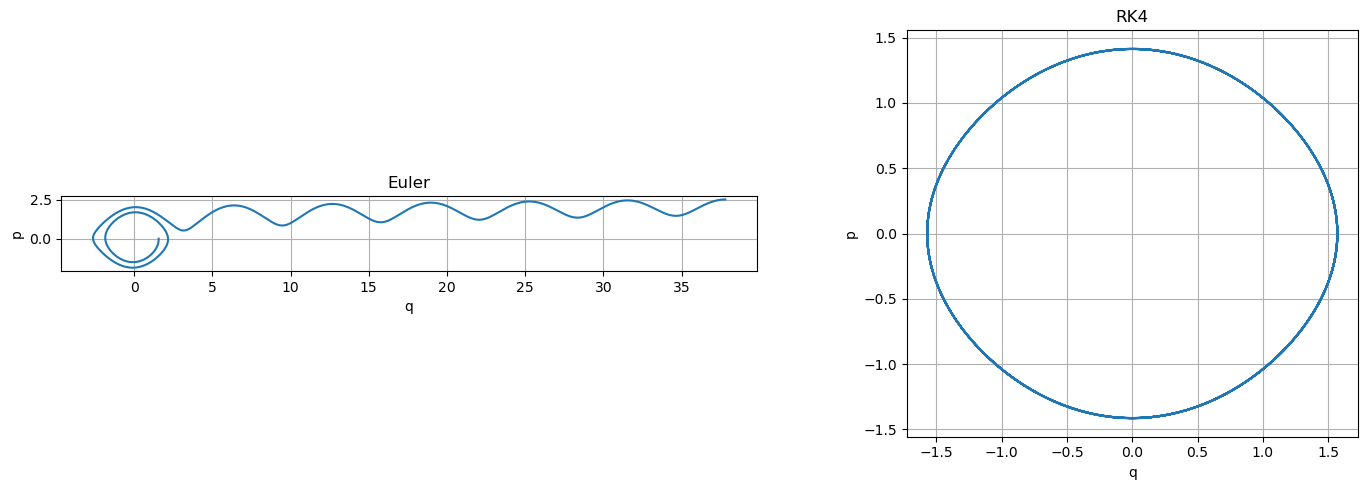

In [3]:
q0 = np.pi/2
p0 = 0.0

dt = 0.1
T = 40

euler = Euler(dt)
rk4 = RK4(dt)

traj_euler = euler.evolve(q0, p0, T)

traj_rk4 = rk4.evolve(q0, p0, T)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plots = [
    ("Euler", traj_euler),
    ("RK4", traj_rk4),
]

for ax, (title, traj) in zip(axes, plots):

    ax.plot(traj.q, traj.p)

    ax.set_title(title)
    ax.set_xlabel("q")
    ax.set_ylabel("p")

    ax.grid(True)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

we can see straight away that Euler's method spirals out of the closed curve an energy conserving system should have into an unbounded energy gaining system. This comes from the accumulating errors of Euler's method. RK4 on the other hand does a great job in recovering the physics of the large angle pendulum

The deviation of the energy of the numerical system from what it started with can be seen through the follwoing plot

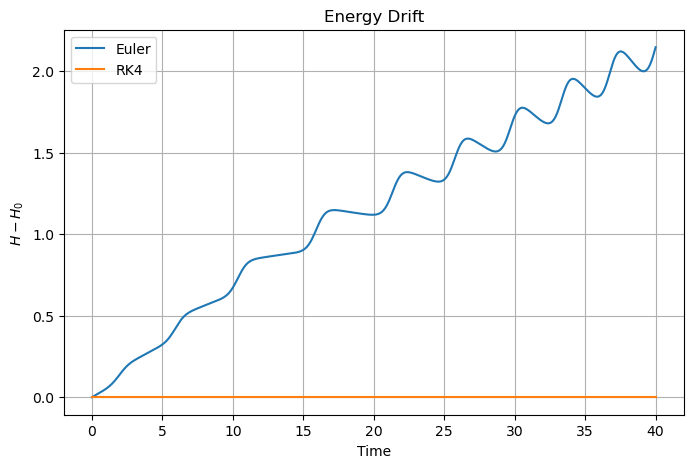

In [7]:
plt.figure(figsize=(8,5))

plt.plot(traj_euler.t,
        traj_euler.energy - traj_euler.energy[0],
         label="Euler")

plt.plot(traj_rk4.t, traj_rk4.energy - traj_rk4.energy[0], label="RK4")


plt.xlabel("Time")
plt.ylabel(r"$H-H_0$")
plt.title("Energy Drift")

plt.grid(True)
plt.legend()

plt.show() 

Euler's method keeps gaining artificial energy while RK4 stays close to the energy of the system for long periods of time. 

## RK4 vs störm-verlet

Even RK4 accumulates errors so given a long enough simulation time, even RK4 develops deviation from energy and artificially stops conserving energy. This can of course be combatted with a numerical method of yet again a higher order but you can have more clever ways. If your main intention of the simulation is to find a numerical evolver that respects the energy constraints, you can symplectic solvers such as störmer-verlet

If we allow the system to run as far as 3000s we can see RK4 starts to show failure while störme-verlet holds up well in its phase-space trajectory. The thickness of RK4 indicates it's started to spiral inward and is therefore artificially losing energy.

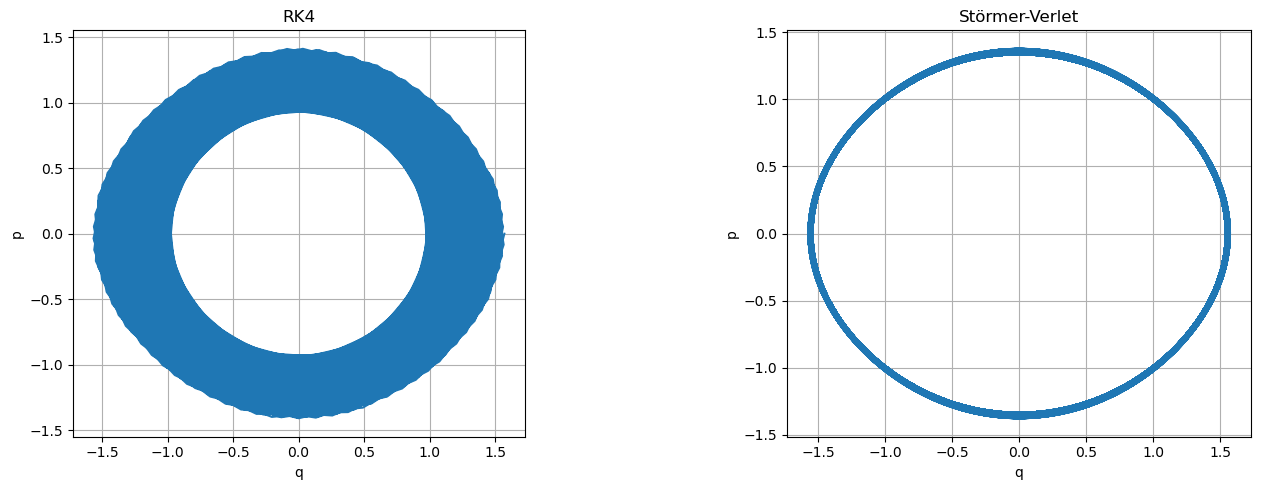

In [8]:
q0 = np.pi/2
p0 = 0.0

dt = 0.5
T = 3000

rk4 = RK4(dt)
verlet = StormerVerlet(dt)


traj_rk4 = rk4.evolve(q0, p0, T)

traj_verlet = verlet.evolve(q0, p0, T)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plots = [
    ("RK4", traj_rk4),
    ("Störmer-Verlet", traj_verlet)
]

for ax, (title, traj) in zip(axes, plots):

    ax.plot(traj.q, traj.p)

    ax.set_title(title)
    ax.set_xlabel("q")
    ax.set_ylabel("p")

    ax.grid(True)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

and if we look at the energies of RK4 and störmer-verlet we obtain the following plot

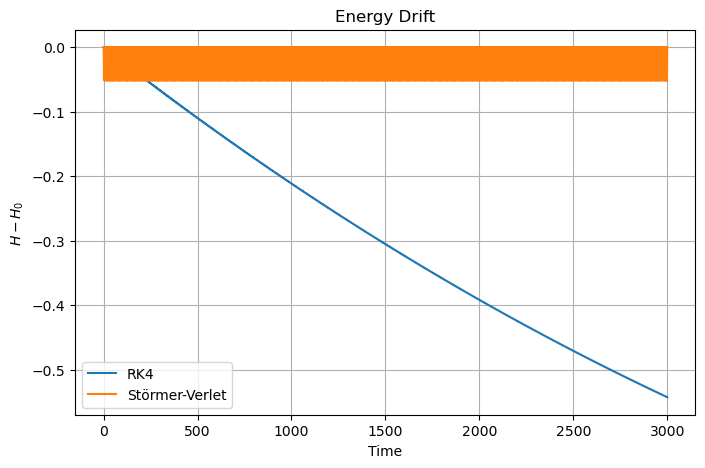

In [9]:
plt.figure(figsize=(8,5))

plt.plot(traj_rk4.t,
         traj_rk4.energy - traj_rk4.energy[0],
         label="RK4")

plt.plot(traj_verlet.t,
         traj_verlet.energy - traj_verlet.energy[0],
         label="Störmer-Verlet")

plt.xlabel("Time")
plt.ylabel(r"$H-H_0$")
plt.title("Energy Drift")

plt.grid(True)
plt.legend()

plt.show()

One thing we realise is that störmer-verlet is actually bounded in the energy it can take. It oscillates within the range from the very start but it stays there. Therefore, for a system that you want to  preserve its energ conserving property, störmer-verlet will always give you results that are in the ballpark of an energy conservation obeying system. RK4 you would notice, for at least until 200s is actually doing better than störmer-verlet in being more energetically accurate. That is because RK4 is indeed more accurate in predicting actual values of position and velocities than other methods being fourth order when störmer-verlet is only second. Yet given enough time, the errors accumulate and RK4 no longer represents the energy of the system accurately. It also loses its precision with the physical variables of the set-up

For a low runtime (200s), you can see RK4 and störmer-verlet are near identical:

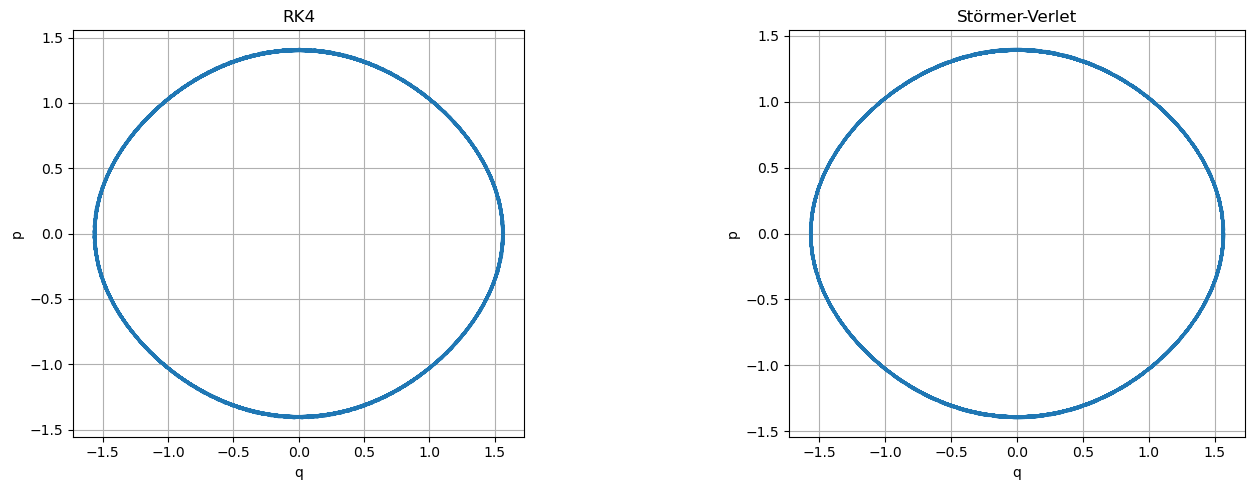

In [11]:
q0 = np.pi/2
p0 = 0.0

dt = 0.3
T = 200

rk4 = RK4(dt)
verlet = StormerVerlet(dt)


traj_rk4 = rk4.evolve(q0, p0, T)

traj_verlet = verlet.evolve(q0, p0, T)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plots = [
    ("RK4", traj_rk4),
    ("Störmer-Verlet", traj_verlet)
]

for ax, (title, traj) in zip(axes, plots):

    ax.plot(traj.q, traj.p)

    ax.set_title(title)
    ax.set_xlabel("q")
    ax.set_ylabel("p")

    ax.grid(True)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

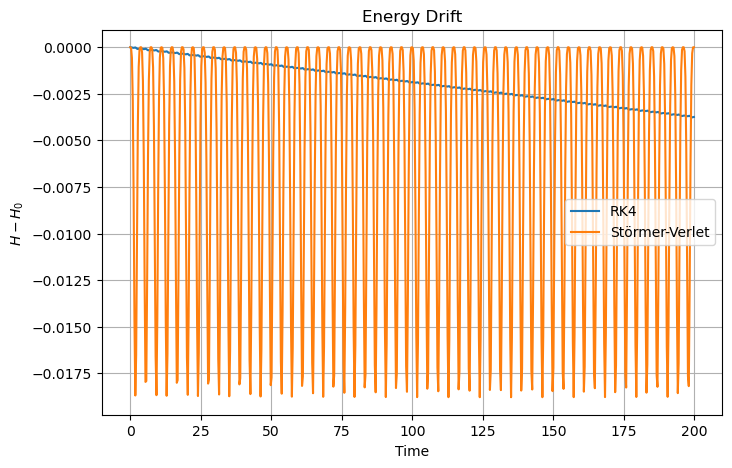

In [12]:
plt.figure(figsize=(8,5))

plt.plot(traj_rk4.t,
         traj_rk4.energy - traj_rk4.energy[0],
         label="RK4")

plt.plot(traj_verlet.t,
         traj_verlet.energy - traj_verlet.energy[0],
         label="Störmer-Verlet")

plt.xlabel("Time")
plt.ylabel(r"$H-H_0$")
plt.title("Energy Drift")

plt.grid(True)
plt.legend()

plt.show()

## Why does the Störmer–Verlet method conserve energy so well?

the Störmer–Verlet method, which is only **second-order accurate**, often conserves energy much better than the **fourth-order Runge–Kutta (RK4)** method over long integrations. The reason lies in its **geometric properties**.

### Symplecticity

Hamiltonian systems possess a geometric structure known as a **symplectic structure**. The exact flow generated by Hamilton's equations preserves this structure, meaning that it conserves the geometry of phase space rather than simply producing accurate pointwise approximations.

The Störmer–Verlet method is a **symplectic integrator**, meaning that every numerical timestep is itself a symplectic transformation. Consequently, the numerical solution preserves the same geometric structure as the true Hamiltonian flow.

Although the method introduces local truncation errors of order

$$
\mathcal{O}(\Delta t^3),
$$

these errors do **not** accumulate in a way that systematically increases or decreases the total energy.

---

### Modified Hamiltonian

A remarkable result from **backward error analysis** is that a symplectic integrator does **not** exactly solve the original Hamiltonian

$$
H(q,p),
$$

but instead exactly solves a nearby **modified Hamiltonian**

$$
\tilde H(q,p)
=
H(q,p)
+
\mathcal{O}(\Delta t^2).
$$

The modified Hamiltonian differs only slightly from the true Hamiltonian, yet it is **exactly conserved** by the numerical method.

Consequently, the true energy satisfies

$$
H(q,p)-\tilde H(q,p)
=
\mathcal{O}(\Delta t^2),
$$

meaning that the numerical energy can only fluctuate by a small amount proportional to $\Delta t^2$.

Instead of drifting steadily away from its initial value, the energy oscillates around the exact value with a bounded error.

This bounded oscillatory behaviour is the defining feature of symplectic integrators and explains their remarkable long-term stability.

---

### Contrast with Runge–Kutta

The classical fourth-order Runge–Kutta method is **not symplectic**. Although each timestep is extremely accurate,

$$
\text{Local error}
=
\mathcal{O}(\Delta t^5),
$$

the method does not preserve the underlying symplectic geometry of Hamiltonian systems.

As a consequence, the tiny energy errors introduced at every timestep accumulate coherently over time. This produces a **secular energy drift**, in which the total energy gradually increases or decreases throughout the simulation.

Initially this drift is extremely small, but over sufficiently long integrations it becomes significant.

Therefore,

- RK4 provides a more accurate approximation over short times.
- Störmer–Verlet provides a much more faithful representation of the long-term dynamics.

---

### Relation to Liouville's Theorem

Liouville's theorem states that the Hamiltonian flow preserves phase-space volume.

Since the Störmer–Verlet method is symplectic, each numerical timestep approximately preserves this same geometric property. Phase-space patches are free to stretch, rotate and shear, but their enclosed area remains nearly constant throughout the simulation.

In contrast, non-symplectic methods such as RK4 gradually distort the underlying geometry. Although these distortions are initially imperceptible, sufficiently long integrations exhibit both energy drift and corresponding deviations from the exact Hamiltonian flow.

---

### Summary

The superior long-term behaviour of the Störmer–Verlet method is therefore **not** a consequence of higher numerical accuracy, but rather of preserving the intrinsic geometric structure of Hamiltonian mechanics.

By respecting the symplectic nature of Hamilton's equations, the method reproduces the qualitative behaviour of the true dynamics over arbitrarily long times. This makes it the preferred numerical integrator for conservative mechanical systems and explains why it is particularly well suited for studying Liouville's theorem and long-term energy conservation.